# 1. Exploration et nettoyage des données

Cette première étape consiste à explorer, comprendre et fiabiliser le jeu de données avant l'entraînement des modèles de régression.

Les principales opérations réalisées sont :
- chargement du jeu de données ;
- vérification de sa structure ;
- analyse des valeurs manquantes ;
- suppression des doublons ;
- imputation des valeurs manquantes ;
- correction des types de données ;
- analyse exploratoire des variables ;
- détection et traitement des valeurs aberrantes ;
- préparation des variables pour la modélisation.

In [467]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1.1 Chargement du jeu de données

Le jeu de données est chargé à l'aide de Pandas. Il contient les informations nécessaires pour prédire le prix de vente de voitures d'occasion.

In [468]:
df = pd.read_csv("../data/car-price.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007.0,60000,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007.0,135000,50000.0,Petrol,Individual,Manual,NaN
2,Hyundai Verna 1.6 SX,2012.0,600000,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017.0,250000,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014.0,450000,141000.0,Diesel,Individual,Manual,Second Owner


## 1.2 Vérification de la structure des données

Avant toute transformation, nous vérifions les types des colonnes, les dimensions du jeu de données et la présence de valeurs manquantes.

Cette vérification permet d'identifier les variables numériques et catégorielles, puis de déterminer les traitements nécessaires.

In [469]:
print("===== TYPES DES COLONNES =====")
print(df.dtypes)

print("\n===== DIMENSIONS =====")
print(df.shape)

print("\n===== VALEURS MANQUANTES =====")
print(df.isnull().sum())

===== TYPES DES COLONNES =====
name                 str
year             float64
selling_price      int64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object

===== DIMENSIONS =====
(4340, 8)

===== VALEURS MANQUANTES =====
name               0
year              43
selling_price      0
km_driven        173
fuel              86
seller_type       65
transmission       0
owner             86
dtype: int64


## 2.1 Détection et suppression des doublons

Les doublons peuvent faire apparaître plusieurs fois une même observation et ainsi fausser l'analyse ou l'apprentissage du modèle.

Nous comptons d'abord les doublons, puis nous les supprimons du jeu de données.

In [470]:
duplicate_count = df.duplicated().sum()

print(f"Nombre de doublons : {duplicate_count}")

df = df.drop_duplicates()

print(f"Dimensions après suppression : {df.shape}")

Nombre de doublons : 635
Dimensions après suppression : (3705, 8)


## 2.2 Traitement des valeurs manquantes

Les valeurs manquantes sont traitées selon la nature de chaque variable.

Pour les variables numériques, nous utilisons des valeurs calculées à partir de groupes de voitures similaires afin de préserver au mieux la structure du jeu de données.

Pour les variables catégorielles, nous utilisons la valeur la plus fréquente, appelée mode, au sein de groupes de voitures similaires.

Cette stratégie évite de supprimer les lignes contenant des valeurs manquantes.

In [471]:
print("===== VALEURS MANQUANTES AVANT IMPUTATION =====")
print(df.isnull().sum())

===== VALEURS MANQUANTES AVANT IMPUTATION =====
name               0
year              43
selling_price      0
km_driven        170
fuel              84
seller_type       65
transmission       0
owner             86
dtype: int64


### 2.2.1 Imputation des variables numériques

Les variables numériques sont complétées avec la médiane, c'est-à-dire la valeur centrale des observations disponibles dans un groupe de voitures similaires.

L'imputation est effectuée progressivement, en utilisant des groupes de plus en plus généraux lorsque l'information nécessaire n'est pas disponible.

#### 2.2.1.1 Imputation de l'année

Pour les voitures dont l'année est manquante, nous utilisons d'abord la moyenne de l'année des voitures portant le même nom.

Si aucune information n'est disponible pour ce groupe, nous utilisons l'intervalle de kilométrage comme groupe de référence.

In [472]:
df["year"] = df["year"].fillna(
    df.groupby("name")["year"]
      .transform("mean")
      .round()
)

df["year"] = df["year"].fillna(
    df.groupby(
        pd.cut(
            df["km_driven"],
            bins=range(
                0,
                int(df["km_driven"].max()) + 50000,
                50000
            )
        )
    )["year"]
    .transform("mean")
    .round()
)

#### 2.2.1.2 Imputation du kilométrage

Pour `km_driven`, la médiane est utilisée car elle est moins sensible aux valeurs extrêmes.

Nous utilisons d'abord les voitures portant le même nom et ayant la même année. Si aucune valeur n'est disponible, nous utilisons la médiane du kilométrage pour la même année.

In [473]:
df["km_driven"] = df["km_driven"].fillna(
    df.groupby(["name", "year"])["km_driven"]
      .transform("median")
      .round()
)

df["km_driven"] = df["km_driven"].fillna(
    df.groupby("year")["km_driven"]
      .transform("median")
      .round()
)

### 2.2.2 Imputation des variables catégorielles

Les variables catégorielles sont complétées avec le mode, c'est-à-dire la valeur la plus fréquente dans un groupe de voitures similaires.

Comme pour les variables numériques, l'imputation est effectuée progressivement avec des groupes de plus en plus généraux.

#### 2.2.2.1 Imputation de la variable `fuel`

La variable `fuel` indique le type de carburant utilisé par le véhicule.

Pour les valeurs manquantes, nous utilisons d'abord le mode des voitures portant le même nom. Si aucune valeur ne peut être déterminée à partir du nom, nous utilisons le mode du type de carburant pour la même année.

In [474]:
df["fuel"] = df["fuel"].fillna(
    df.groupby("name")["fuel"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)

df["fuel"] = df["fuel"].fillna(
    df.groupby("year")["fuel"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)

#### 2.2.2.2 Imputation de la variable `seller_type`

La variable `seller_type` indique le type de vendeur du véhicule.

Pour les valeurs manquantes, nous recherchons d'abord le mode parmi les véhicules ayant le même type de propriétaire (`owner`) et la même année.

Si la valeur reste manquante, nous utilisons ensuite le mode des véhicules portant le même nom et ayant la même année.

In [475]:
df["seller_type"] = df["seller_type"].fillna(
    df.groupby(["owner", "year"])["seller_type"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)

df["seller_type"] = df["seller_type"].fillna(
    df.groupby(["name", "year"])["seller_type"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)

#### 2.2.2.3 Imputation de la variable `owner`

La variable `owner` représente le nombre ou le type de propriétaire précédent du véhicule.

Pour les valeurs manquantes, nous utilisons le mode des véhicules ayant le même type de vendeur (`seller_type`) et la même année.

Cette stratégie exploite les relations entre le type de vendeur, l'année du véhicule et son historique de propriété.

In [476]:
df["owner"] = df["owner"].fillna(
    df.groupby(["seller_type", "year"])["owner"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)

### 2.2.3 Vérification après traitement

Après l'imputation, nous vérifions à nouveau les valeurs manquantes afin de confirmer que les colonnes concernées ont été correctement complétées.

In [477]:
print("===== VALEURS MANQUANTES APRÈS IMPUTATION =====")
print(df.isnull().sum())

===== VALEURS MANQUANTES APRÈS IMPUTATION =====
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


## 2.3 Correction des types de données

Après le traitement des valeurs manquantes, les variables numériques `year` et `km_driven` sont converties en entiers afin d'obtenir une structure de données cohérente.

In [478]:
df["year"] = df["year"].astype(int)
df["km_driven"] = df["km_driven"].astype(int)

print(df.dtypes)

name               str
year             int64
selling_price    int64
km_driven        int64
fuel               str
seller_type        str
transmission       str
owner              str
dtype: object


In [479]:
print("Dimensions finales après nettoyage :", df.shape)

Dimensions finales après nettoyage : (3705, 8)


# 3. Analyse statistique descriptive

Nous réalisons une première analyse statistique afin de mieux comprendre la distribution des variables numériques.

Les principales statistiques étudiées sont :
- la moyenne ;
- la médiane ;
- l'écart-type ;
- le minimum ;
- le maximum ;
- les quartiles.

In [480]:
df.describe()

,year,selling_price,km_driven
count,3705.000000,3.705000e+03,3705.000000
mean,2012.975978,4.753006e+05,68731.426991
std,4.234706,5.095973e+05,47081.951291
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,35299.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [481]:
print("===== FREQUENCES =====")

for col in ["fuel", "seller_type", "transmission", "owner"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

===== FREQUENCES =====

--- fuel ---
fuel
Diesel      1858
Petrol      1784
CNG           39
LPG           23
Electric       1
Name: count, dtype: int64

--- seller_type ---
seller_type
Individual          2931
Dealer               735
Trustmark Dealer      39
Name: count, dtype: int64

--- transmission ---
transmission
Manual       3378
Automatic     327
Name: count, dtype: int64

--- owner ---
owner
First Owner             2318
Second Owner            1006
Third Owner              290
Fourth & Above Owner      74
Test Drive Car            17
Name: count, dtype: int64


## 3.1 Distribution du kilométrage et du prix

Les histogrammes permettent d'observer la distribution de `km_driven` et de `selling_price`, ainsi que d'identifier une éventuelle asymétrie ou la présence de valeurs extrêmes.

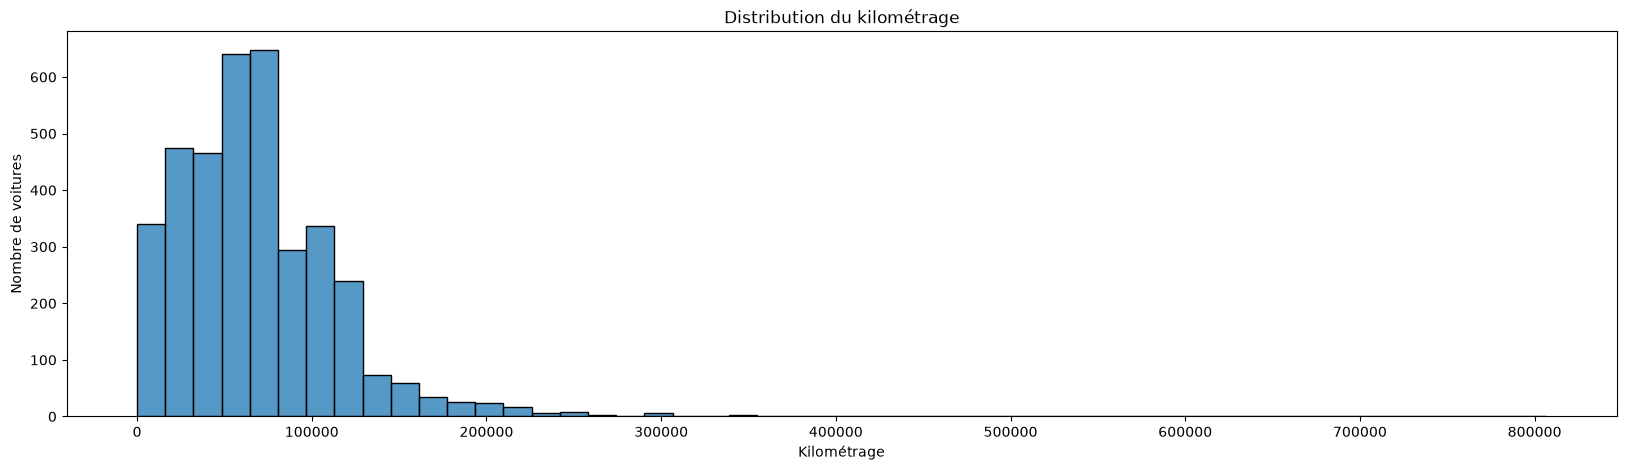

In [482]:
plt.figure(figsize=(20, 5))
sns.histplot(df["km_driven"], bins=50)
plt.xlabel("Kilométrage")
plt.ylabel("Nombre de voitures")
plt.title("Distribution du kilométrage")
plt.show()

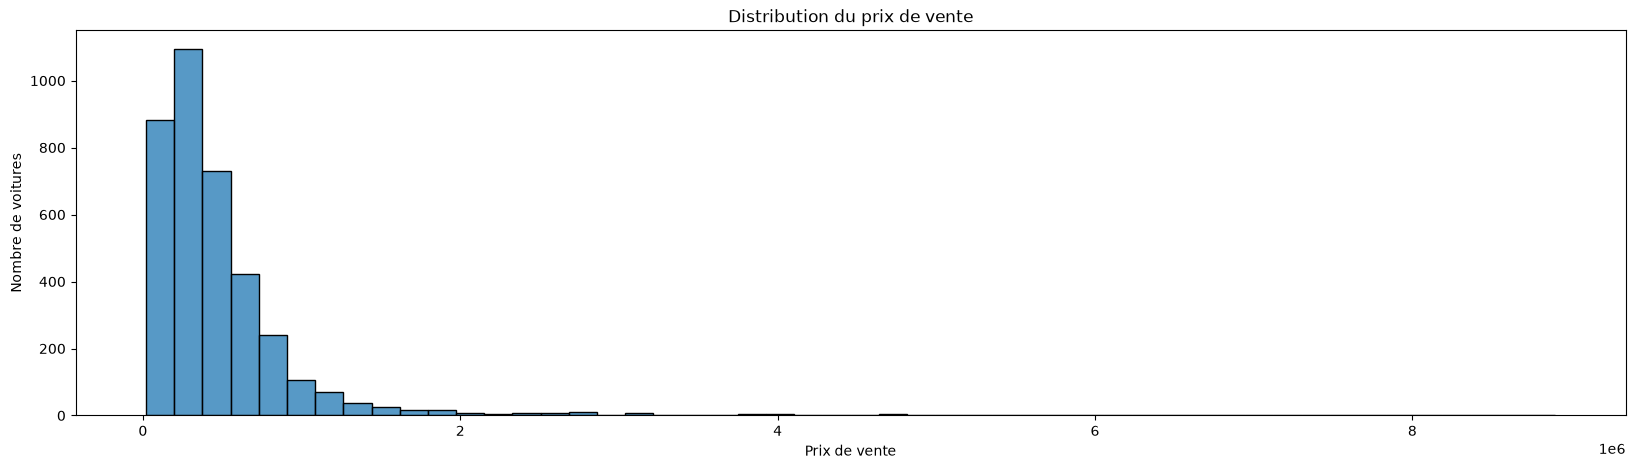

In [483]:
plt.figure(figsize=(20, 5))
sns.histplot(df["selling_price"], bins=50)
plt.xlabel("Prix de vente")
plt.ylabel("Nombre de voitures")
plt.title("Distribution du prix de vente")
plt.show()

## 3.2 Impact de l'année et du kilométrage sur le prix

Nous visualisons les relations entre `year`, `km_driven` et `selling_price` afin d'identifier les tendances présentes dans les données.

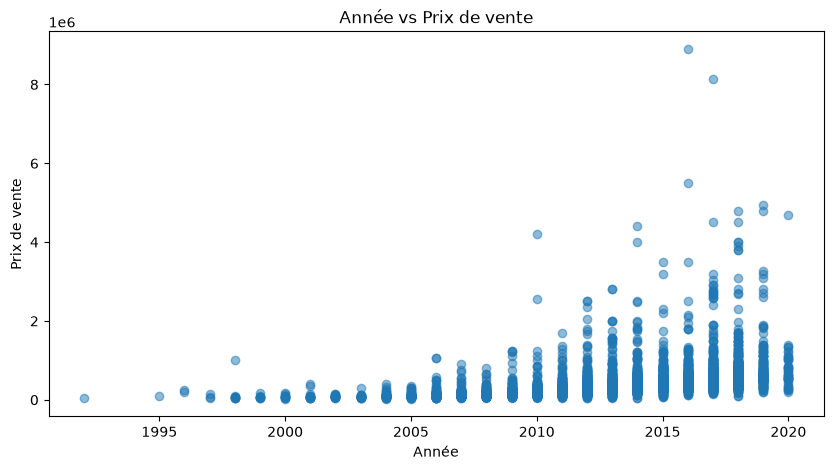

In [484]:
plt.figure(figsize=(10, 5))
plt.scatter(df["year"], df["selling_price"], alpha=0.5)
plt.xlabel("Année")
plt.ylabel("Prix de vente")
plt.title("Année vs Prix de vente")
plt.show()

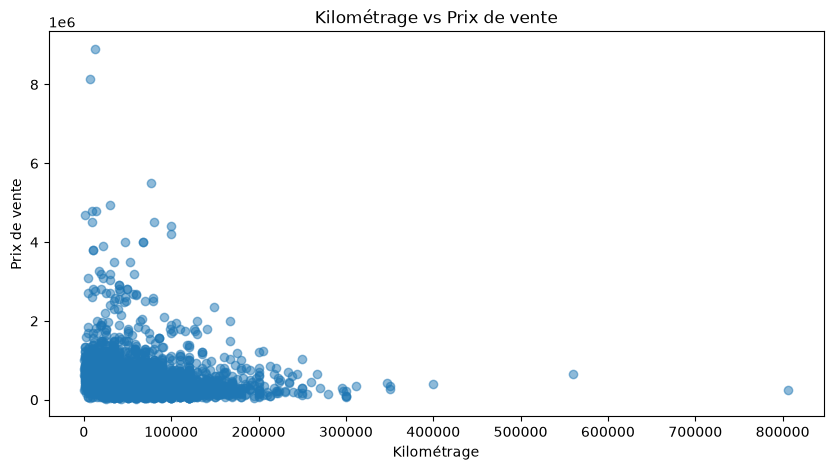

In [485]:
plt.figure(figsize=(10, 5))
plt.scatter(df["km_driven"], df["selling_price"], alpha=0.5)
plt.xlabel("Kilométrage")
plt.ylabel("Prix de vente")
plt.title("Kilométrage vs Prix de vente")
plt.show()

## 3.3 Détection des valeurs aberrantes

Les valeurs aberrantes peuvent influencer fortement les performances des modèles de régression.

Nous utilisons des boîtes à moustaches pour identifier visuellement les observations extrêmes dans les variables `selling_price`, `km_driven` et `year`.

/tmp/ipykernel_5527/4294902973.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


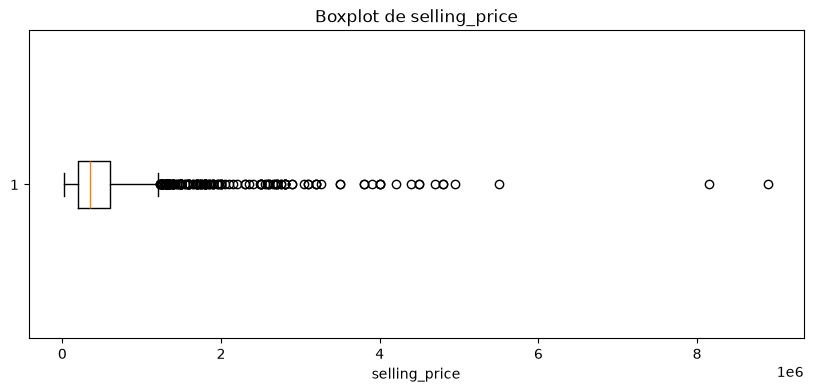

/tmp/ipykernel_5527/4294902973.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


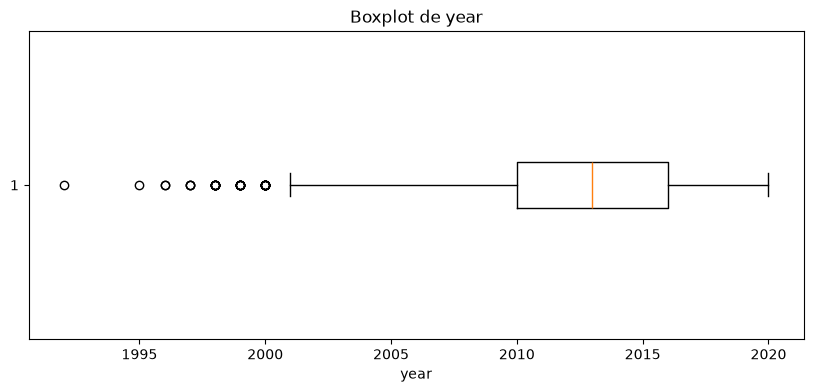

/tmp/ipykernel_5527/4294902973.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


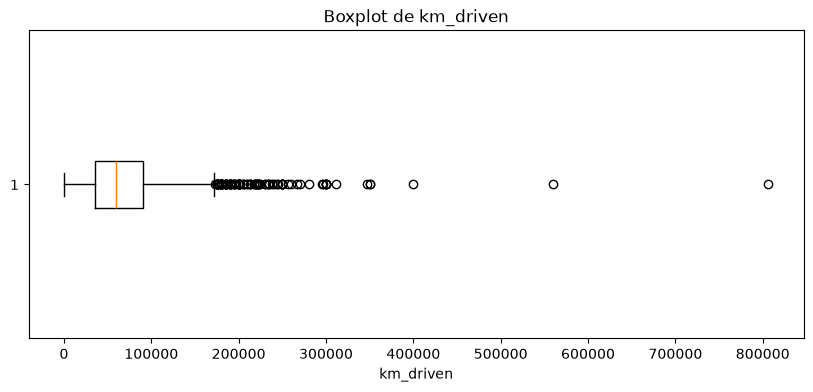

In [486]:
columns = ["selling_price", "year", "km_driven"]

for col in columns:
    plt.figure(figsize=(10, 4))
    plt.boxplot(df[col], vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot de {col}")
    plt.show()

# 4. Traitement des valeurs aberrantes

## 4.1 Valeurs aberrantes du prix

La variable `selling_price` représente le prix de vente du véhicule. Des valeurs aberrantes peuvent influencer les statistiques et réduire les performances du modèle de prédiction.

Pour détecter ces valeurs, la méthode de l'**IQR (Interquartile Range)** est appliquée séparément à chaque modèle de voiture (`name`). Cette approche compare le prix d'un véhicule à ceux des autres véhicules portant le même nom, plutôt qu'à l'ensemble du jeu de données.

Pour chaque groupe, nous calculons :
- **Q1** : premier quartile, correspondant à 25 % des valeurs ;
- **Q3** : troisième quartile, correspondant à 75 % des valeurs ;
- **IQR** : différence entre Q3 et Q1 ;
- **borne inférieure** : `Q1 - 1.5 × IQR` ;
- **borne supérieure** : `Q3 + 1.5 × IQR`.

Une tolérance de **5 000 DH** est ajoutée aux deux bornes afin d'éviter de supprimer des valeurs très proches des prix habituels du même modèle, en particulier dans les groupes contenant peu d'observations.

Le filtrage est appliqué séparément à chaque groupe `name`, puis les groupes nettoyés sont recombinés dans le DataFrame final.

In [487]:
def clean_sellingPrice_outliers(cars):

    cars["name"] = cars.name
    cars = cars[["name"] + [col for col in cars.columns if col != "name"]]

    Q1 = cars["selling_price"].quantile(0.25)
    Q3 = cars["selling_price"].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    tolerance = 5000

    return cars[
        (cars["selling_price"] >= lower - tolerance)
        & (cars["selling_price"] <= upper + tolerance)
    ]


print(f"Before : {df.shape}")
df = (
    df.groupby("name", group_keys=False)
    .apply(clean_sellingPrice_outliers)
    .reset_index(drop=True)
)
print(f"After : {df.shape}")

Before : (3705, 8)
After : (3624, 8)


## 4.2 Valeurs aberrantes de l'année

La variable `year` représente l'année de fabrication du véhicule. Afin d'identifier les années qui s'éloignent de la distribution habituelle d'un même modèle, une méthode basée sur les quartiles est appliquée à chaque groupe `name`.

Pour chaque groupe, nous calculons le premier et le troisième quartile. Une **tolérance de 2 ans** est ajoutée aux limites :
- **borne inférieure** : `Q1 - 2` ;
- **borne supérieure** : `Q3 + 2`.

Les véhicules dont l'année se situe en dehors de cet intervalle sont considérés comme potentiellement aberrants et sont exclus du jeu de données.

In [488]:
def clean_year_outliers(cars):

    cars["name"] = cars.name
    cars = cars[["name"] + [col for col in cars.columns if col != "name"]]

    lower = cars["year"].quantile(0.25)
    upper = cars["year"].quantile(0.75)

    tolerance = 2

    return cars[
        (cars["year"] >= lower - tolerance) & (cars["year"] <= upper + tolerance)
    ]


print(f"Before : {df.shape}")
df = (
    df.groupby("name", group_keys=False)
    .apply(clean_year_outliers)
    .reset_index(drop=True)
)
print(f"After : {df.shape}")

Before : (3624, 8)
After : (3553, 8)


## 4.3 Valeurs aberrantes du kilométrage

La variable `km_driven` représente le kilométrage parcouru par le véhicule. Des valeurs extrêmes peuvent influencer le modèle de prédiction ou résulter d'erreurs ou d'observations atypiques.

Pour identifier ces valeurs, la méthode de l'**IQR (Interquartile Range)** est appliquée aux groupes définis par `name` et `year`.

Ce regroupement permet de comparer le kilométrage de véhicules ayant le même modèle et la même année. Pour chaque groupe, nous calculons :
- **Q1** : premier quartile ;
- **Q3** : troisième quartile ;
- **IQR** : `Q3 - Q1` ;
- **borne inférieure** : `Q1 - 1.5 × IQR` ;
- **borne supérieure** : `Q3 + 1.5 × IQR`.

Les observations situées en dehors de ces limites sont considérées comme aberrantes et supprimées du jeu de données.

In [489]:
def clean_kmDriven_outliers(cars):

    cars["name"], cars["year"] = cars.name

    cars = cars[
        ["name", "year"] + [col for col in cars.columns if col not in ["name", "year"]]
    ]

    Q1 = cars["km_driven"].quantile(0.25)
    Q3 = cars["km_driven"].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return cars[(cars["km_driven"] >= lower) & (cars["km_driven"] <= upper)]


print(f"Before : {df.shape}")
df = (
    df.groupby(["name", "year"], group_keys=False)
    .apply(clean_kmDriven_outliers)
    .reset_index(drop=True)
)
print(f"After : {df.shape}")

Before : (3553, 8)
After : (3497, 8)


## 5. Matrice de corrélation

La matrice de corrélation permet d'étudier les relations entre les variables numériques, notamment l'influence potentielle de l'année et du kilométrage sur le prix de vente.

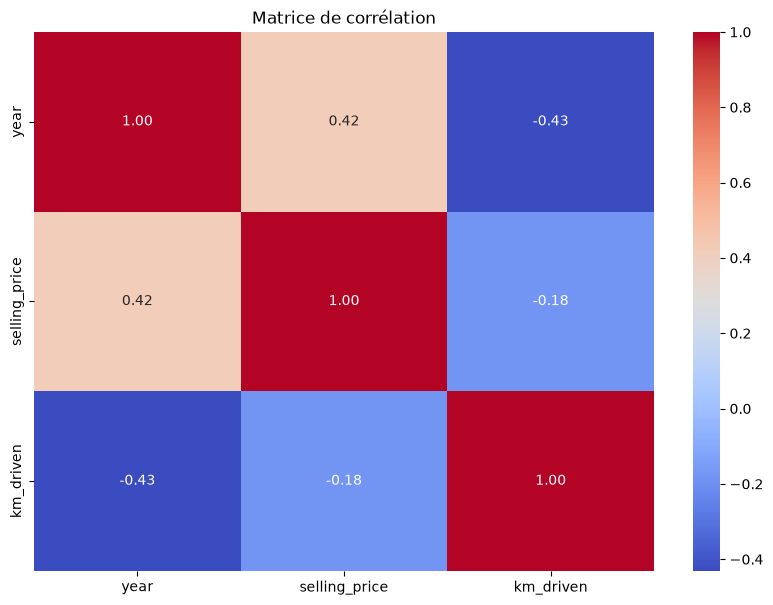

In [490]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")
plt.show()

## 6. Encodage des variables catégoriques

Les variables catégoriques doivent être transformées en valeurs numériques afin de pouvoir être utilisées par les algorithmes de Machine Learning.

Dans notre dataset, les variables catégoriques sont fuel, seller_type, transmission et owner. La méthode d'encodage est choisie en fonction de la nature de chaque variable.

### 6.1 Encodage de la variable `fuel`

La variable `fuel` contient plusieurs catégories telles que `Diesel`, `Petrol`, `CNG`, `LPG` et `Electric`.

Ces catégories ne possèdent pas d'ordre naturel. Pour cette raison, un **One-Hot Encoding** est utilisé afin de transformer chaque catégorie en une variable binaire contenant `0` ou `1`.

Cette méthode permet de convertir la variable `fuel` en valeurs numériques tout en évitant d'introduire une relation d'ordre artificielle entre les différentes catégories.


In [491]:
df = pd.get_dummies(
    df,
    columns=["fuel"],
    dtype=int
)

### 6.2 Encodage de la variable `seller_type`

La variable `seller_type` contient plusieurs catégories telles que `Individual`, `Dealer` et `Trustmark Dealer`.

Ces catégories ne possèdent pas d'ordre naturel. Un **One-Hot Encoding** est donc utilisé afin de transformer chaque catégorie en une variable binaire contenant `0` ou `1`.

Cette méthode permet de représenter les différents types de vendeurs sous forme numérique sans introduire de relation d'ordre artificielle entre les catégories.


In [492]:
df = pd.get_dummies(
    df,
    columns=["seller_type"],
    dtype=int
)

### 6.3 Encodage de la variable `transmission`

La variable `transmission` contient uniquement deux catégories : `Manual` et `Automatic`.

Comme cette variable possède seulement deux valeurs possibles, un encodage binaire est utilisé. La catégorie `Manual` est représentée par `0`, tandis que `Automatic` est représentée par `1`.

Cette transformation permet de convertir directement la variable catégorielle en une variable numérique adaptée aux algorithmes de Machine Learning.


In [493]:
df["transmission"] = df["transmission"].map({
    "Manual": 0,
    "Automatic": 1
})

### 6.4 Encodage de la variable `owner`

La variable `owner` représente le nombre de propriétaires précédents du véhicule. Elle contient les catégories `First Owner`, `Second Owner`, `Third Owner` et `Fourth & Above Owner`, qui suivent un ordre naturel.

Un **Ordinal Encoding** est donc utilisé afin d'associer une valeur numérique à chaque niveau de propriété : `1` pour le premier propriétaire, `2` pour le deuxième, `3` pour le troisième et `4` pour le quatrième propriétaire ou plus.

La catégorie `Test Drive Car` représente un cas particulier qui ne correspond pas à un nombre de propriétaires. Elle est donc représentée par `0`.


In [494]:
df["owner"] = df["owner"].map({
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 0
})

## 7. Séparation des données

### 7.1 Séparation en ensembles d'entraînement et de test

Après le nettoyage des données et l'encodage des variables catégoriques, les données sont séparées en deux ensembles : un ensemble d'entraînement et un ensemble de test.

La variable `selling_price` est définie comme variable cible (`target`), car elle représente le prix que le modèle devra prédire. Les autres variables utilisées pour effectuer cette prédiction constituent les variables explicatives (`features`).

Les données sont ensuite divisées avec `train_test_split` selon une proportion de **80 % pour l'entraînement et 20 % pour le test**.

L'ensemble d'entraînement est utilisé pour apprendre les relations entre les caractéristiques des véhicules et leur prix, tandis que l'ensemble de test est conservé pour évaluer les performances du modèle sur des données qu'il n'a pas vues pendant l'entraînement.

Le paramètre `random_state=42` permet de conserver le même découpage des données à chaque exécution.


In [495]:
X = df.drop(["selling_price", "name"], axis=1)
y = df["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X data for train : {X_train.shape}")
print(f"X data for test  : {X_test.shape}")
print(f"y data for train : {y_train.shape}")
print(f"y data for test  : {y_test.shape}")

X data for train : (2797, 12)
X data for test  : (700, 12)
y data for train : (2797,)
y data for test  : (700,)


In [496]:
numeric_cols = ["year", "km_driven"]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train[numeric_cols].describe())

               year     km_driven
count  2.797000e+03  2.797000e+03
mean   8.503268e-15  1.397206e-16
std    1.000179e+00  1.000179e+00
min   -4.326204e+00 -1.453186e+00
25%   -7.185259e-01 -6.883279e-01
50%    3.009623e-03 -1.784085e-01
75%    7.245452e-01  4.589908e-01
max    1.686593e+00  1.568431e+01


In [497]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "SVR": SVR()
}

results = []

for name, model in models.items():

    # Training
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    })

results_df = pd.DataFrame(results)
results_df["R² (%)"] = results_df["R²"] * 100

results_df.to_csv("../data/baseline_results.csv", index=False)

In [498]:
df.to_csv("../data/output.csv", index=False)